# LightFM Feature Importance vs Accuracy

This notebook uses the processed dataset to estimate which item features help or hurt LightFM accuracy.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.dataloader.ratings_splitter import RatingsSplitter
from src.evaluation import LightFMFeatureInfluenceAnalyzer
from src.evaluation import LightFMFeatureInfluenceConfig

/home/samuel/Documents/data-mining-recommender-systems/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Processed Data

We load cleaned ratings and movie features from `data/processed`.

In [2]:
project_root_path = Path.cwd()
if not (project_root_path / "src").exists():
    project_root_path = project_root_path.parent

ratings_path = project_root_path / "data" / "processed" / "ratings_train_cleaned.csv"
movies_path = project_root_path / "data" / "processed" / "movies_cleaned.csv"

ratings_dataframe = pd.read_csv(ratings_path)
movies_dataframe = pd.read_csv(movies_path)

print(f"Ratings rows: {len(ratings_dataframe)}")
print(f"Movies rows: {len(movies_dataframe)}")

Ratings rows: 97801
Movies rows: 9742


## Create Train/Validation Split

To keep enough train signal, we hold out 30% interactions for only 50 users. Users with <= 1 interaction are excluded.

In [3]:
splitter = RatingsSplitter(
    val_fraction=0.3,
    min_interactions=2,
    seed=42,
    max_validation_users=50,
)

train_dataframe, validation_dataframe = splitter.split(ratings_dataframe)

print(f"Train rows: {len(train_dataframe)}")
print(f"Validation rows: {len(validation_dataframe)}")
print(f"Validation users: {validation_dataframe['userId'].nunique()}")

Train rows: 95251
Validation rows: 2550
Validation users: 50


## Run Feature Influence Analysis

This performs one-feature-at-a-time ablation and compares RMSE against the baseline model.

- Positive influence score: removing feature makes RMSE worse (feature helps).
- Negative influence score: removing feature improves RMSE (feature hurts).

In [4]:
influence_config = LightFMFeatureInfluenceConfig(
    metric_name="rmse_value",
    number_of_recommendations=10,
    relevance_threshold=4.0,
    number_of_components=16,
    number_of_epochs=5,
    learning_rate_value=0.03,
    loss_name="warp",
    random_seed=42,
)

analyzer = LightFMFeatureInfluenceAnalyzer(influence_config=influence_config)
feature_influence_dataframe = analyzer.analyze(
    train_dataframe=train_dataframe,
    validation_dataframe=validation_dataframe,
    movies_dataframe=movies_dataframe,
)

feature_influence_dataframe.head(20)

,feature_name,baseline_metric_value,ablated_metric_value,influence_score,influence_direction
0,release_year,6.107436,6.381244,0.273808,positive
1,genre_Comedy,6.107436,6.358350,0.250914,positive
2,genre_Thriller,6.107436,6.263994,0.156559,positive
3,genre_Action,6.107436,6.232003,0.124567,positive
4,genre_Sci-Fi,6.107436,6.229149,0.121713,positive
5,genre_Adventure,6.107436,6.200646,0.093210,positive
6,genre_Romance,6.107436,6.197197,0.089761,positive
7,genre_Crime,6.107436,6.176933,0.069497,positive
8,genre_Drama,6.107436,6.174518,0.067082,positive
9,genre_War,6.107436,6.150932,0.043496,positive


## Best Positive and Negative Features

Here we inspect the strongest contributors and the strongest harmful features.

In [5]:
top_positive_features = feature_influence_dataframe.head(10).copy()
top_negative_features = feature_influence_dataframe.tail(10).copy()

print("Top positive features (help RMSE):")
display(top_positive_features[["feature_name", "influence_score", "influence_direction"]])

print("Top negative features (hurt RMSE):")
display(top_negative_features[["feature_name", "influence_score", "influence_direction"]])

,feature_name,influence_score,influence_direction
11,genre_IMAX,0.027349,positive
12,genre_Western,0.025598,positive
13,genre_Fantasy,0.025259,positive
14,genre_Mystery,0.019467,positive
15,genre_Children,0.016939,positive
16,genre_(no genres listed),-0.013885,negative
17,genre_Film-Noir,-0.016340,negative
18,genre_Animation,-0.062037,negative
19,genre_Horror,-0.079908,negative
20,genre_Documentary,-0.120907,negative


## Visualize Feature Influence

Bars above zero help accuracy (lower RMSE), bars below zero hurt it.

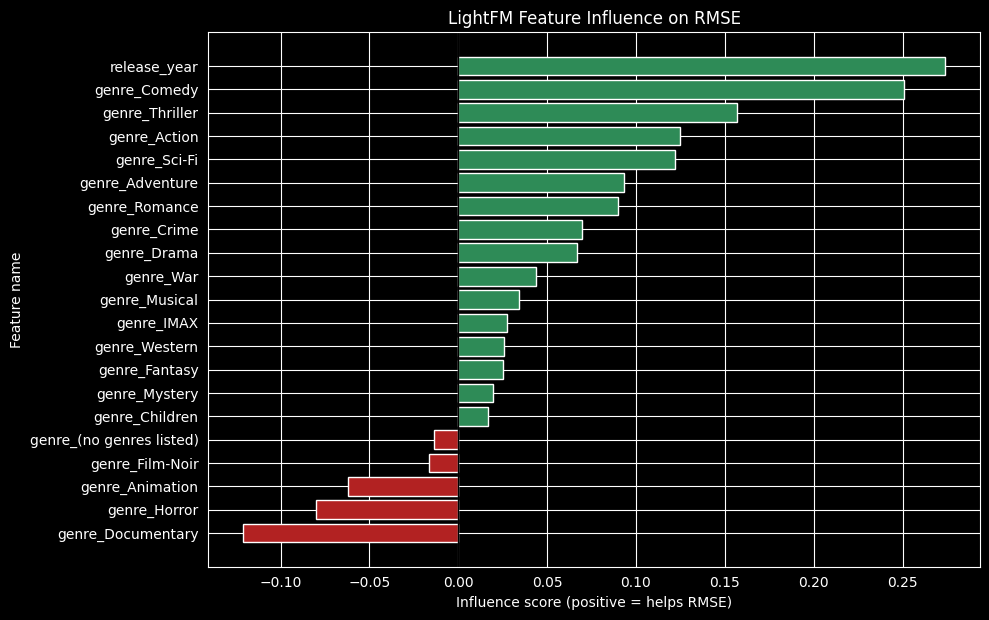

In [6]:
plot_dataframe = feature_influence_dataframe.sort_values("influence_score", ascending=True).copy()
plot_colors = ["#2E8B57" if value >= 0 else "#B22222" for value in plot_dataframe["influence_score"]]

plt.figure(figsize=(10, max(6, len(plot_dataframe) * 0.3)))
plt.barh(plot_dataframe["feature_name"], plot_dataframe["influence_score"], color=plot_colors)
plt.axvline(0.0, color="black", linewidth=1)
plt.title("LightFM Feature Influence on RMSE")
plt.xlabel("Influence score (positive = helps RMSE)")
plt.ylabel("Feature name")
plt.tight_layout()
plt.show()